In [1]:
import numpy as np
import matplotlib.pyplot as plt
import json

In [2]:
def load_data(folder, exact_file):
    if exact_file == "spectral_stats":
        return np.load(f"{folder}/{exact_file}.npz")
    elif exact_file == "metrics_results":
        with open(f"{folder}/metrics_results.json") as f:
            data = json.load(f)
        print(data)
        print(" ")
        f.close()
        return data
    elif exact_file == "physical_stats":
        return np.load(f"{folder}/{exact_file}.npz")

In [19]:
G = [0.0, 1.0]
gt = None
Gs = []
Gs80k = []
exact_file = "metrics_results"

"""
prefix = "/cluster/work/math/braonic/TrainedModels/OOD_Generalization/pdegym_plus/PDEGYM_PLUS_10ep_ViTB_regression/predictions_spectral_resolver_64_steps_1_ensemble_True_renorm_"
sufix = "_guidance_eul_riemann_curved_"
"""


prefix = "/cluster/work/math/braonic/TrainedModels/OOD_Generalization/pdegym_plus/PDEGYM_PLUS_10ep_ViTB_regression/finetuned/ns_shear_gencfd/pdegym_plus_10k_FT_ns_shear_gencfd_non_native_10000/predictions_spectral_resolver_64_steps_1_ensemble_True_renorm_"
sufix = "_guidance_ns_shear_gencfd_"


for i, guidance in enumerate(G):
    folder = f"{prefix}{str(guidance)}{sufix}"
    print("Guidance is ", guidance)
    data = load_data(folder, exact_file)
    
    if exact_file == "spectral_stats":
        if i == 0 :
            gt = np.mean(data['spectrum_gt'], axis = 0)
        Gs.append(np.mean(data['spectrum_gen'], axis = 0))

prefix = "/cluster/work/math/braonic/TrainedModels/OOD_Generalization/pdegym_plus/PDEGYM_PLUS_10ep_ViTB_regression/finetuned/ns_shear_gencfd/pdegym_plus_80k_FT_ns_shear_gencfd_non_native_80000/predictions_spectral_resolver_64_steps_1_ensemble_True_renorm_"
sufix = "_guidance_ns_shear_gencfd_"
for i, guidance in enumerate(G):
    folder = f"{prefix}{str(guidance)}{sufix}"
    print("Guidance is ", guidance)
    data = load_data(folder, exact_file)
    
    if exact_file == "spectral_stats":
        if i == 0 :
            gt = np.mean(data['spectrum_gt'], axis = 0)
        Gs80k.append(np.mean(data['spectrum_gen'], axis = 0))



Guidance is  0.0
{'mean': {'relative': [0.011370142921805382, 0.5201989412307739], 'absolute': [0.0079695088788867, 0.009043151512742043]}, 'std': {'relative': [0.02938869781792164, 0.018739191815257072], 'absolute': [0.010557153262197971, 0.009900298900902271]}, 'wasserstein_distance': {'wass_0': 0.023305116221308708, 'wass_1': 0.027676910161972046}, 'determinsitic_l1': [0.11443648919521365], 'determinsitic_relative_l1': [0.20514087779156398]}
 
Guidance is  1.0
{'mean': {'relative': [0.01168349664658308, 0.47731414437294006], 'absolute': [0.008189142681658268, 0.008297641761600971]}, 'std': {'relative': [0.06618784368038177, 0.04530252888798714], 'absolute': [0.023776324465870857, 0.023934256285429]}, 'wasserstein_distance': {'wass_0': 0.024376990273594856, 'wass_1': 0.028128931298851967}, 'determinsitic_l1': [0.09311308865289902], 'determinsitic_relative_l1': [0.16696248663356528]}
 
Guidance is  0.0
{'mean': {'relative': [0.01051260158419609, 0.510847270488739], 'absolute': [0.0073

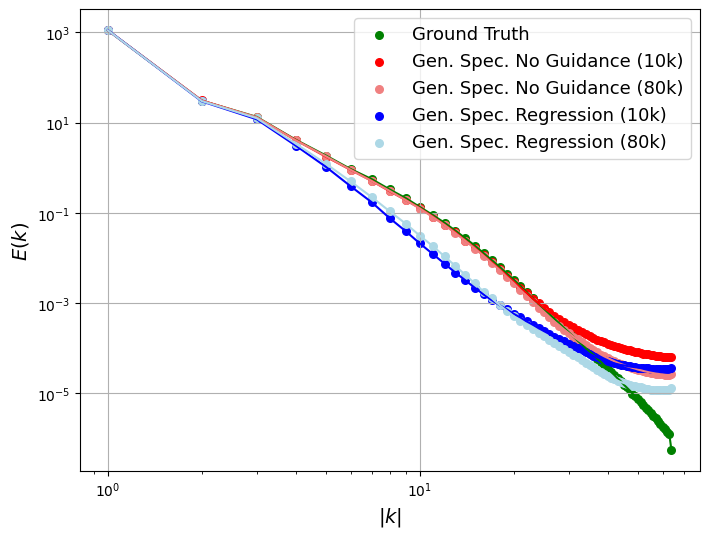

In [14]:
save_fig = True

fig, ax = plt.subplots(figsize=(8, 6))

plt.scatter(np.arange(1, np.shape(gt[1:,0])[0]+1), gt[1:,0], label = "Ground Truth",color = "green", s =30)#, axis = 0))
plt.plot(np.arange(1, np.shape(gt[1:,0])[0]+1), gt[1:,0],color = "green")#, axis = 0))

for i,g in enumerate(G):

    if g == 0.0:
        color = "red"
        plt.scatter(np.arange(1, np.shape(gt[1:,0])[0]+1), Gs[i][1:,0], label = "Gen. Spec. No Guidance (10k)", color = "red", s =30)#, axis = 0))
        plt.plot(np.arange(1, np.shape(gt[1:,0])[0]+1), Gs[i][1:,0],color = "red")#, axis = 0))

        plt.scatter(np.arange(1, np.shape(gt[1:,0])[0]+1), Gs80k[i][1:,0], label = "Gen. Spec. No Guidance (80k)", color = "lightcoral", s =30)#, axis = 0))
        plt.plot(np.arange(1, np.shape(gt[1:,0])[0]+1), Gs80k[i][1:,0],color = "lightcoral")#, axis = 0))
    elif g == 1.0:
        plt.scatter(np.arange(1, np.shape(gt[1:,0])[0]+1), Gs[i][1:,0], label = "Gen. Spec. Regression (10k)", color = "blue", s =30)#, axis = 0))
        plt.plot(np.arange(1, np.shape(gt[1:,0])[0]+1), Gs[i][1:,0], color = "blue")#, axis = 0))

        plt.scatter(np.arange(1, np.shape(gt[1:,0])[0]+1), Gs80k[i][1:,0], label = "Gen. Spec. Regression (80k)", color = "lightblue", s =30)#, axis = 0))
        plt.plot(np.arange(1, np.shape(gt[1:,0])[0]+1), Gs80k[i][1:,0], color = "lightblue")#, axis = 0))
    else:
        plt.scatter(np.arange(1, np.shape(gt[1:,0])[0]+1), Gs[i][1:,0], label = f"Gen. Spec. $g = {g}$", s =30)#, axis = 0))
        plt.plot(np.arange(1, np.shape(gt[1:,0])[0]+1), Gs[i][1:,0])#, axis = 0))

plt.grid(True)
plt.xlabel(r'$|k|$',fontsize = 14)
plt.ylabel(r'$E(k)$',fontsize = 14)
plt.xscale("log")
plt.yscale("log")
plt.legend(fontsize = 13)

if save_fig:
    if "eul_riemann_curved" in prefix or "eul_riemann_curved" in sufix:
        plt.savefig(f"/cluster/home/braonic/ViT_FM/Figures/eul_riemann_curved_spectral/eul_riemann_curved_spectral_estimated_spectra.pdf", dpi = 400)
        plt.savefig(f"/cluster/home/braonic/ViT_FM/Figures/eul_riemann_curved_spectral/eul_riemann_curved_spectral_estimated_spectra.png", dpi = 400)
    if "ns_shear" in prefix or "ns_shear" in sufix:
        plt.savefig(f"/cluster/home/braonic/ViT_FM/Figures/ns_shear_gencfd/ns_shear_gencfd_spectral_estimated_spectra.pdf", dpi = 400)
        plt.savefig(f"/cluster/home/braonic/ViT_FM/Figures/ns_shear_gencfd/ns_shear_gencfd_spectral_estimated_spectra.png", dpi = 400)


In [17]:
prefix = "/cluster/work/math/braonic/TrainedModels/OOD_Generalization/pdegym_plus/PDEGYM_PLUS_10ep_ViTB_regression/finetuned/ns_shear_gencfd/pdegym_plus_80k_FT_ns_shear_gencfd_non_native_80000/predictions_spectral_resolver_64_steps_1_ensemble_True_renorm_"
sufix = "_guidance_ns_shear_gencfd_"

channels = 2
G = [0.0, 1.0]
W = np.zeros((channels, len(G)))

"""
G = [0.0, 0.1, 0.15, 0.2, 0.25, 0.4, 0.5, 0.75, 1.0]
W = np.zeros((4, len(G)))
prefix = "/cluster/work/math/braonic/TrainedModels/OOD_Generalization/pdegym_plus/PDEGYM_PLUS_10ep_ViTB_regression/predictions_spectral_resolver_64_steps_1_ensemble_True_renorm_"
sufix = "_guidance_eul_riemann_curved_"
"""
for i,guidance in enumerate(G):
    folder = f"{prefix}{str(guidance)}{sufix}"
    with open(f"{folder}/metrics_results.json") as f:
        M = json.load(f)
    
    for j in range(channels):
        wass = M['wasserstein_distance'][f"wass_{j}"]
        W[j,i] = wass


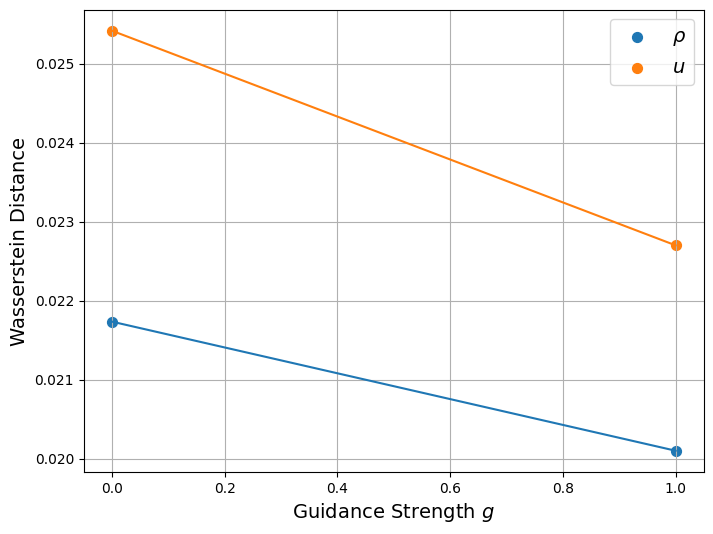

In [18]:
save_fig = False

fig, ax = plt.subplots(figsize=(8, 6))

plt.scatter(G,W[0], s = 50, label = r'$\rho$')
plt.plot(G,W[0])
plt.scatter(G,W[1], s = 50, label = r'$u$')
plt.plot(G,W[1])
plt.grid()

plt.xlabel(r'Guidance Strength $g$',fontsize = 14)
plt.ylabel(r'Wasserstein Distance',fontsize = 14)

plt.legend(fontsize = 14)

if save_fig:
    plt.savefig(f"/cluster/home/braonic/ViT_FM/Figures/eul_riemann_curved_spectral/eul_riemann_curved_wass_distance.pdf", dpi = 400)
    plt.savefig(f"/cluster/home/braonic/ViT_FM/Figures/eul_riemann_curved_spectral/eul_riemann_curved_wass_distance.png", dpi = 400)



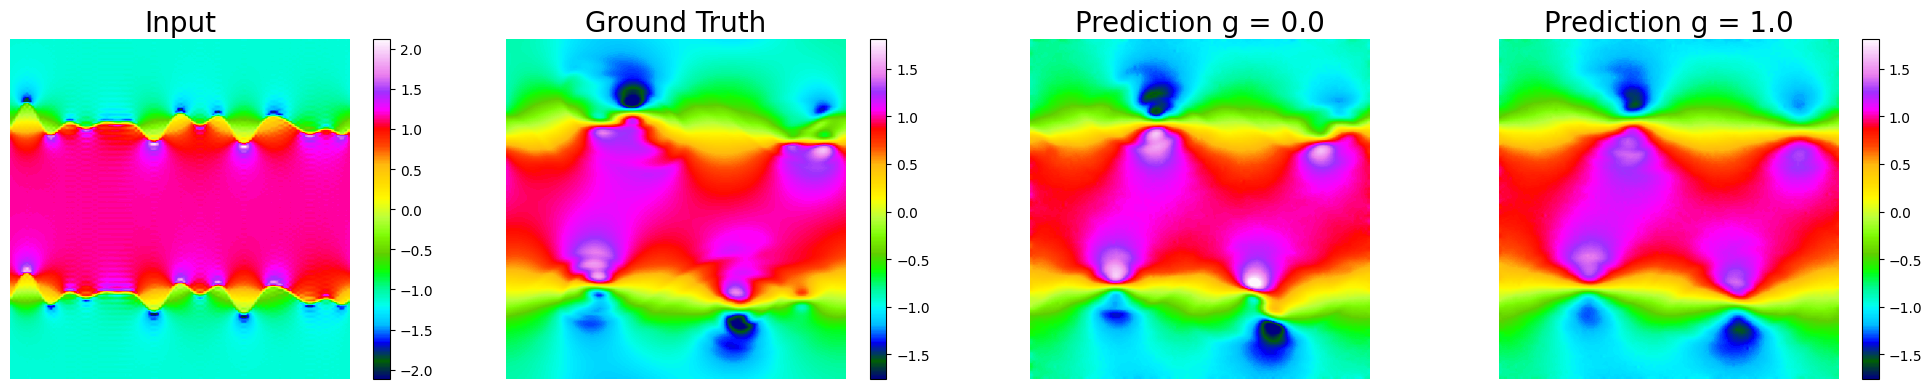

In [35]:
import numpy as np
import matplotlib.pyplot as plt

'''
prefix = "/cluster/work/math/braonic/TrainedModels/OOD_Generalization/pdegym_plus/PDEGYM_PLUS_10ep_ViTB_regression/predictions_spectral_resolver_64_steps_1_ensemble_True_renorm_"
sufix = "_guidance_eul_riemann_curved_"
'''

prefix = "/cluster/work/math/braonic/TrainedModels/OOD_Generalization/pdegym_plus/PDEGYM_PLUS_10ep_ViTB_regression/finetuned/ns_shear_gencfd/pdegym_plus_10k_FT_ns_shear_gencfd_non_native_10000/predictions_spectral_resolver_64_steps_1_ensemble_True_renorm_"
sufix = "_guidance_ns_shear_gencfd_"


G = [0.0, 1.0]
out = None
inp = None
preds = []
id = 23

save_fig = True

W = np.zeros((4, len(G)))
for i,guidance in enumerate(G):
    #folder = f"{prefix}{str(guidance)}{sufix}"
    if i == 0:
        inp = np.load(f"{folder}/sample_{id}_steps_1_1.0_inp.npy")
        out = np.load(f"{folder}/sample_{id}_steps_1_1.0_out.npy")
    preds.append(np.load(f"{folder}/sample_{id}_steps_1_1.0_pred.npy"))



c = 0
c_gt = 1

vmin = np.min(out[c_gt])*0.9
vmax = np.max(out[c_gt])*1.1

fig, axes = plt.subplots(1, len(G)+2, figsize=((len(G)+2)*4 + 4, 4))
cmap = "gist_ncar"

im1 = axes[0].imshow(inp[c_gt], cmap=cmap)#, vmin = vmin, vmax = vmax)
axes[0].set_title("Input", fontsize = 20)
axes[0].axis('off')

# Show each image
im2 = axes[1].imshow(out[c_gt], cmap=cmap, vmin = vmin, vmax = vmax)
axes[1].set_title('Ground Truth', fontsize = 20)
axes[1].axis('off')

# Show each image
for (i,g) in enumerate(G):
    im = axes[2+i].imshow(preds[i][c], cmap=cmap, vmin = vmin, vmax = vmax)
    axes[2+i].set_title(f"Prediction g = {g}", fontsize = 20)
    axes[2+i].axis('off')

fig.colorbar(im1,orientation='vertical')
fig.colorbar(im2,orientation='vertical')
fig.colorbar(im,orientation='vertical')
plt.tight_layout()
    

if save_fig:
    if "eul_riemann_curved" in prefix or "eul_riemann_curved" in sufix:
        plt.savefig(f"/cluster/home/braonic/ViT_FM/Figures/eul_riemann_curved_spectral/eul_riemann_curved_PREDs_sample_{id}_channel_{c}.pdf", dpi = 400)
        plt.savefig(f"/cluster/home/braonic/ViT_FM/Figures/eul_riemann_curved_spectral/eul_riemann_curved_PREDs_sample_{id}_channel_{c}.png", dpi = 400)
    if "ns_shear" in prefix or "ns_shear" in sufix:
        plt.savefig(f"/cluster/home/braonic/ViT_FM/Figures/ns_shear_gencfd/ns_shear_gencfd_PREDs_sample_{id}_channel_{c}.pdf", dpi = 400)
        plt.savefig(f"/cluster/home/braonic/ViT_FM/Figures/ns_shear_gencfd/ns_shear_gencfd_PREDs_sample_{id}_channel_{c}.png", dpi = 400)

plt.show()





NpzFile '/cluster/work/math/braonic/TrainedModels/OOD_Generalization/pdegym_plus/PDEGYM_PLUS_10ep_ViTB_regression/finetuned/ns_shear_gencfd/pdegym_plus_80k_FT_ns_shear_gencfd_non_native_80000/predictions_spectral_resolver_64_steps_1_ensemble_True_renorm_0.0_guidance_ns_shear_gencfd_mm_10_macro/predictions_spectral_resolver_64_steps_1_ensemble_True_renorm_0.0_guidance_MMcurr_9_512_ns_shear_gencfd_mm_/physical_stats.npz' with keys: mean_gen, mean_gt, std_gen, std_gt, gen_samples...
0.046328057
0.059290823


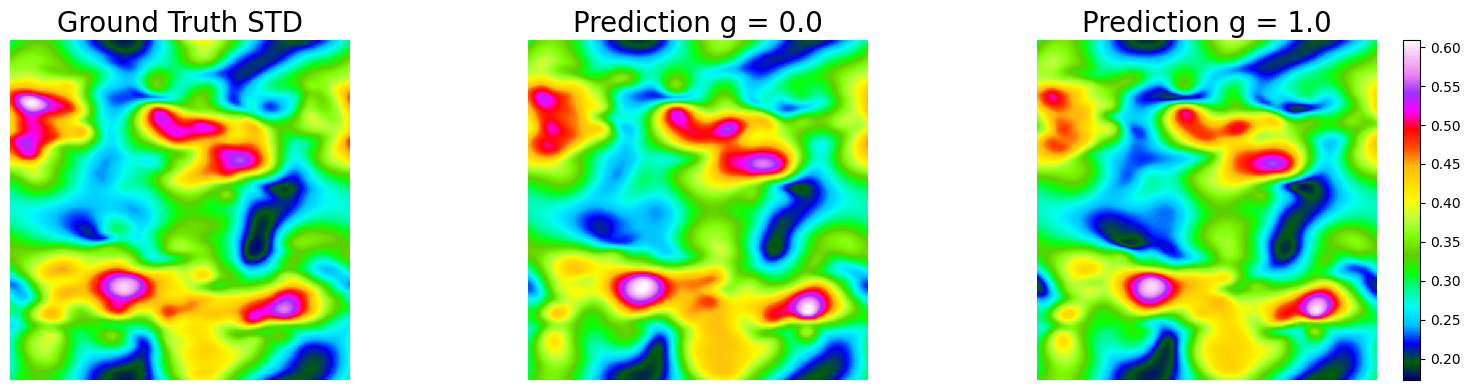

In [42]:
save_fig = False

which = "STD"
G = [0.0, 1.0]
folders = ["/cluster/work/math/braonic/TrainedModels/OOD_Generalization/pdegym_plus/PDEGYM_PLUS_10ep_ViTB_regression/finetuned/ns_shear_gencfd/pdegym_plus_80k_FT_ns_shear_gencfd_non_native_80000/predictions_spectral_resolver_64_steps_1_ensemble_True_renorm_0.0_guidance_ns_shear_gencfd_mm_10_macro/predictions_spectral_resolver_64_steps_1_ensemble_True_renorm_0.0_guidance_MMcurr_9_512_ns_shear_gencfd_mm_", 
           "/cluster/work/math/braonic/TrainedModels/OOD_Generalization/pdegym_plus/PDEGYM_PLUS_10ep_ViTB_regression/finetuned/ns_shear_gencfd/pdegym_plus_80k_FT_ns_shear_gencfd_non_native_80000/predictions_spectral_resolver_64_steps_1_ensemble_True_renorm_1.0_guidance_ns_shear_gencfd_mm_10_macro/predictions_spectral_resolver_64_steps_1_ensemble_True_renorm_1.0_guidance_MMcurr_9_512_ns_shear_gencfd_mm_"]
gt_mean = None
gt_std = None
means = []
stds = []
c = 0
for i, guidance in enumerate(G):
    if folders is None:
        folder = f"{prefix}{str(guidance)}{sufix}"
    else:
        folder = folders[i]
    data = load_data(folder, "physical_stats")
    if i == 0:
        print(data)
        gt_mean = data['mean_gt'][c]
        gt_std = data["std_gt"][c]
    means.append(data['mean_gen'][c])
    stds.append(data['std_gen'][c])

if which == "MEAN":
    gt = gt_mean
    pred = means
elif which == "STD":
    gt = gt_std
    pred = stds


print(np.mean(abs(gt - pred[0]))/np.mean(abs(gt)))
print(np.mean(abs(gt - pred[-1]))/np.mean(abs(gt)))

vmin = np.min(gt)
vmax = np.max(gt)

fig, axes = plt.subplots(1, len(G)+1, figsize=((len(G)+1)*4 + 4, 4))
cmap = "gist_ncar"

axes[0].imshow(gt, cmap=cmap)#, vmin = vmin, vmax = vmax)
axes[0].set_title(f"Ground Truth {which}", fontsize = 20)
axes[0].axis('off')

# Show each image
for (i,g) in enumerate(G):
    im = axes[1+i].imshow(pred[i], cmap=cmap, vmin = vmin, vmax = vmax)
    axes[1+i].set_title(f"Prediction g = {g}", fontsize = 20)
    axes[1+i].axis('off')

fig.colorbar(im,orientation='vertical')
plt.tight_layout()


if save_fig:
    if "eul_riemann_curved" in prefix or "eul_riemann_curved" in sufix:
        plt.savefig(f"/cluster/home/braonic/ViT_FM/Figures/eul_riemann_curved_spectral/eul_riemann_curved_STATISTICS_{which}_channel_{c}.pdf", dpi = 400)
        plt.savefig(f"/cluster/home/braonic/ViT_FM/Figures/eul_riemann_curved_spectral/eul_riemann_curved_STATISTICS_{which}_channel_{c}.png", dpi = 400)
    elif "ns_shear" in prefix or "ns_shear" in sufix:
        plt.savefig(f"/cluster/home/braonic/ViT_FM/Figures/ns_shear_gencfd/ns_shear_gencfd_STATISTICS_{which}_channel_{c}.pdf", dpi = 400)
        plt.savefig(f"/cluster/home/braonic/ViT_FM/Figures/ns_shear_gencfd/ns_shear_gencfd_STATISTICS_{which}_channel_{c}.png", dpi = 400)
plt.show()





In [41]:
file00 = "/cluster/work/math/braonic/TrainedModels/OOD_Generalization/pdegym_plus/PDEGYM_PLUS_10ep_ViTB_regression/finetuned/ns_shear_gencfd/pdegym_plus_80k_FT_ns_shear_gencfd_non_native_80000/predictions_spectral_resolver_64_steps_1_ensemble_True_renorm_0.0_guidance_ns_shear_gencfd_mm_10_macro/metrics_results_mm_10_512.json"
file10 = "/cluster/work/math/braonic/TrainedModels/OOD_Generalization/pdegym_plus/PDEGYM_PLUS_10ep_ViTB_regression/finetuned/ns_shear_gencfd/pdegym_plus_80k_FT_ns_shear_gencfd_non_native_80000/predictions_spectral_resolver_64_steps_1_ensemble_True_renorm_1.0_guidance_ns_shear_gencfd_mm_10_macro/metrics_results_mm_10_512.json"
with open(file00) as f:
    data = json.load(f)
print("guidance 0.0")
print(data)
print(" ")
f.close()

with open(file10) as f:
    data = json.load(f)
print("guidance 1.0")
print(data)
print(" ")
f.close()

guidance 0.0
{'mean': {'relative': [0.03303701709955931, 0.16186891496181488], 'absolute': [0.02610829845070839, 0.026340248063206673]}, 'std': {'relative': [0.07872547954320908, 0.06534320116043091]}, 'wasserstein_distance': {'wass_0': 0.04952433332800865, 'wass_1': 0.04760323464870453}, 'deterministic_rel': [0.1694224216043949]}
 
guidance 1.0
{'mean': {'relative': [0.03295674081891775, 0.16246391832828522], 'absolute': [0.026045861653983593, 0.026326200924813747]}, 'std': {'relative': [0.09862427785992622, 0.08544973656535149]}, 'wasserstein_distance': {'wass_0': 0.056797489523887634, 'wass_1': 0.05762434005737305}, 'deterministic_rel': [0.13351941481232643]}
 


<br>
<br>
<br>
<br>
<br>
<br>
<br>
<br>
<br>
<br>
<br>
<br>
<br>
<br>
<br>
<br>


In [3]:
id = 12 #np.random.randint(240)
c = 0
time = 1.0
#tag = "tmp256"
ensemble = 1
tag = f"tmp64_ensemble{ensemble}"

folder_resolver = f"predictions_spectral_resolver_eul_riemann_curved_{tag}"
pred_resolver = np.load(f"/cluster/work/math/braonic/TrainedModels/OOD_Generalization/pdegym_plus/PDEGYM_PLUS_10ep_ViTB_regression/{folder_resolver}/sample_{id}_steps_1_{time}_pred.npy")
pred_regression = np.load(f"/cluster/work/math/braonic/TrainedModels/OOD_Generalization/pdegym_plus/PDEGYM_PLUS_10ep_ViTB_regression/predictions_pure_regression_eul_riemann_curved_tmp64/sample_{id}_steps_1_{time}_pred.npy")
out = np.load(f"/cluster/work/math/braonic/TrainedModels/OOD_Generalization/pdegym_plus/PDEGYM_PLUS_10ep_ViTB_regression/{folder_resolver}/sample_{id}_steps_1_{time}_out.npy")
out = out[:4]
pred_regression = pred_regression[:4]

vmin = np.min(pred_regression[c])
vmax = np.max(pred_regression[c])

# Create subplots: 1 row, 3 columns
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

# Show each image
axes[0].imshow(pred_resolver[c], cmap='seismic', vmin = vmin, vmax = vmax)
axes[0].set_title(f'Spectral Prediction (Ensemble {ensemble})')
axes[0].axis('off')

axes[1].imshow(out[c], cmap='seismic', vmin = vmin, vmax = vmax)
axes[1].set_title('Ground Truth')
axes[1].axis('off')

im = axes[2].imshow(pred_regression[c], cmap='seismic', vmin = vmin, vmax = vmax)
axes[2].set_title('Regression Prediction')
axes[2].axis('off')
fig.colorbar(im,orientation='vertical')

plt.tight_layout()
plt.show()

#------------------------

vmin1 = np.min(abs(pred_regression[c]-out[c]))
vmax1 = np.max(abs(pred_regression[c]-out[c]))*0.5

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

im = axes[0].imshow(pred_resolver[c] - pred_regression[c], cmap = "seismic", vmin = vmin, vmax = vmax)
axes[0].set_title("Spectral - Regression")
fig.colorbar(im,orientation='vertical')
axes[0].axis('off')

# Show each image
axes[1].imshow(abs(pred_resolver[c]-out[c]), cmap='seismic', vmin = vmin1, vmax = vmax1)
axes[1].set_title('|Spectral - GT|')
axes[1].axis('off')

im1 = axes[2].imshow(abs(pred_regression[c]-out[c]), cmap='seismic', vmin = vmin1, vmax = vmax1)
axes[2].set_title('|Regression -GT|')
axes[2].axis('off')

fig.colorbar(im1,orientation='vertical')

plt.tight_layout()
plt.show()

err_reg = np.mean(abs(out - pred_regression), axis = (1,2))/ np.mean(abs(out) + 1e-10, axis = (1,2))

#---------

ensembles = [1,8]
vmin = np.min(out[c])
vmax = np.max(out[c])

# Create subplots: 1 row, 3 columns
fig, axes = plt.subplots(1, len(ensembles) + 2, figsize=(5*(len(ensembles) + 2)+1, 4))

for i,ensemble in enumerate(ensembles):
    tag = f"tmp64_ensemble{ensemble}"

    folder_resolver = f"predictions_spectral_resolver_eul_riemann_curved_{tag}"
    pred_resolver = np.load(f"/cluster/work/math/braonic/TrainedModels/OOD_Generalization/pdegym_plus/PDEGYM_PLUS_10ep_ViTB_regression/{folder_resolver}/sample_{id}_steps_1_{time}_pred.npy")

    axes[i].imshow(pred_resolver[c], cmap='seismic', vmin = vmin, vmax = vmax)
    axes[i].set_title(f'Spectral Prediction (Ensemble {ensemble})')
    axes[i].axis('off')
    
    err_spec = np.mean(abs(out - pred_resolver), axis = (1,2))/ np.mean(abs(out) + 1e-10, axis = (1,2))
    print(err_spec, "ensemble ", ensemble, " spectral")

axes[-2].imshow(pred_regression[c], cmap='seismic', vmin = vmin, vmax = vmax)
axes[-2].set_title('Regression Prediction')
axes[-2].axis('off')

im = axes[-1].imshow(out[c], cmap='seismic', vmin = vmin, vmax = vmax)
axes[-1].set_title('Ground Truth')
axes[-1].axis('off')
fig.colorbar(im,orientation='vertical')
print(err_reg, " regression")
plt.show()



FileNotFoundError: [Errno 2] No such file or directory: '/cluster/work/math/braonic/TrainedModels/OOD_Generalization/pdegym_plus/PDEGYM_PLUS_10ep_ViTB_regression/predictions_spectral_resolver_eul_riemann_curved_tmp64_ensemble1/sample_12_steps_1_1.0_pred.npy'

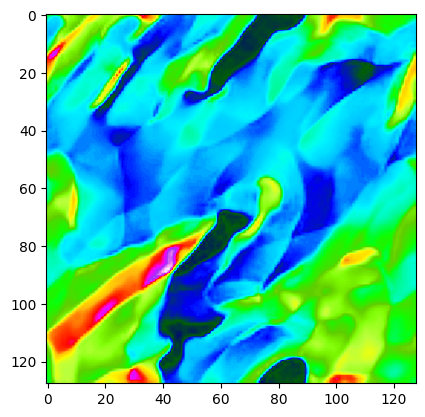

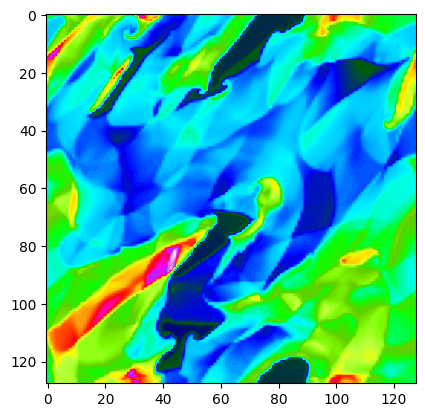

In [61]:
plt.imshow(u, cmap = 'gist_ncar')
plt.show()
plt.imshow(u_gt, cmap = 'gist_ncar')
#plt.show()
#plt.imshow(u_gt2, cmap = 'gist_ncar')

In [28]:
ds_gt2["rho"].shape

(10000, 21, 128, 128)

In [39]:
out[1]

array([[-0.99944836, -1.0048888 , -1.010315  , ..., -0.98499775,
        -0.9896158 , -0.9946302 ],
       [-1.0043998 , -1.0095638 , -1.0152866 , ..., -0.9894005 ,
        -0.99434435, -0.99908304],
       [-1.0089895 , -1.0145572 , -1.019858  , ..., -0.9928492 ,
        -0.99825054, -1.0038494 ],
       ...,
       [-0.98464394, -0.98987955, -0.99578875, ..., -0.9713966 ,
        -0.97524047, -0.9795094 ],
       [-0.98948246, -0.9949569 , -1.0005306 , ..., -0.9759252 ,
        -0.97998375, -0.98471624],
       [-0.9944294 , -0.999579  , -1.0054575 , ..., -0.9808242 ,
        -0.9850417 , -0.9893531 ]], dtype=float32)

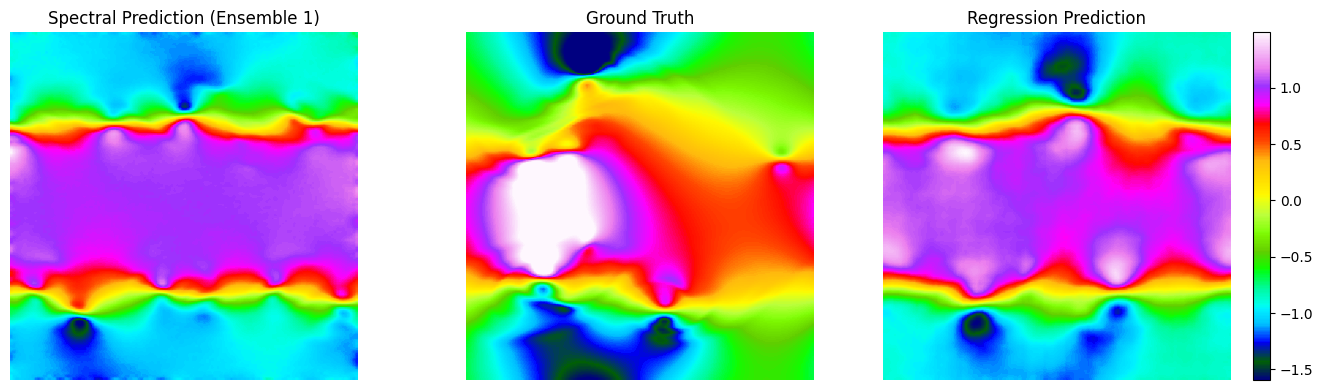

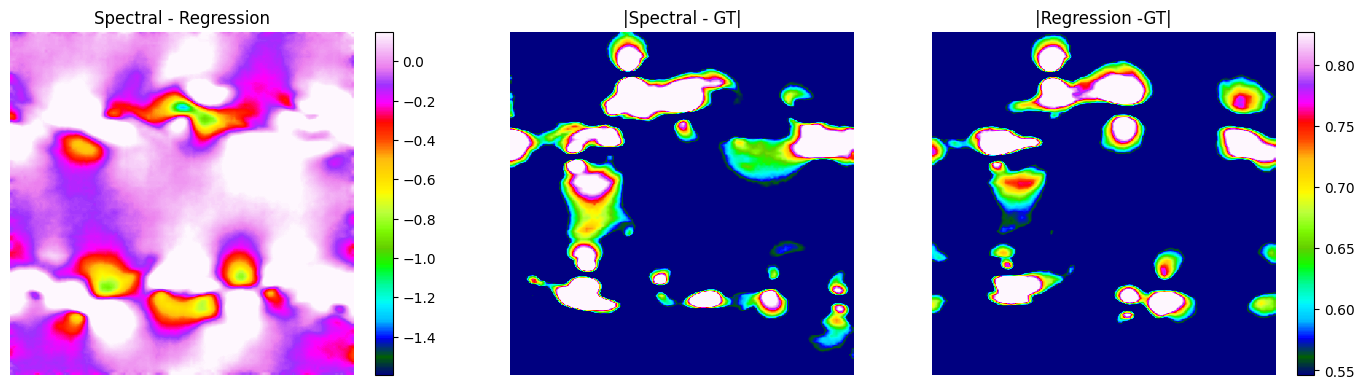

[0.49855408 0.9317844 ]
[0.5569205 1.0350131]


In [22]:
import numpy as np
import matplotlib.pyplot as plt


id = 1 #np.random.randint(240)
c = 0
c_gt = 1
time = 1.0
#tag = "tmp256"
ensemble = 1
num_steps = 64
guidance = 0.1
renorm = True
cmap = "gist_ncar"

folder_resolver = f"predictions_spectral_resolver_64_steps_1_ensemble_True_renorm_0.0_guidance_ns_shear_gencfd_"
folder_regression = "predictions_pure_regression_True_renorm_ns_shear_gencfd_"
model_folder = "/cluster/work/math/braonic/TrainedModels/OOD_Generalization/pdegym_plus/PDEGYM_PLUS_10ep_ViTB_regression"

pred_resolver = np.load(f"{model_folder}/{folder_resolver}/sample_{id}_steps_1_{time}_pred.npy")
pred_regression = np.load(f"{model_folder}/{folder_regression}/sample_{id}_steps_1_{time}_pred.npy")
out = np.load(f"{model_folder}/{folder_resolver}/sample_{id}_steps_1_{time}_out.npy")

to_resolver = np.load(f"{model_folder}/{folder_resolver}/sample_{id}_steps_1_{time}_2trainer.npy")
to_trainer = np.load(f"{model_folder}/{folder_resolver}/sample_{id}_steps_1_{time}_2resolver.npy")

out = out[:4]
pred_regression = pred_regression[:4]

vmin = np.min(pred_regression[c])
vmax = np.max(pred_regression[c])

# Create subplots: 1 row, 3 columns
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

# Show each image
axes[0].imshow(pred_resolver[c], cmap=cmap, vmin = vmin, vmax = vmax)
axes[0].set_title(f'Spectral Prediction (Ensemble {ensemble})')
axes[0].axis('off')

axes[1].imshow(out[c_gt], cmap=cmap, vmin = vmin, vmax = vmax)
axes[1].set_title('Ground Truth')
axes[1].axis('off')

im = axes[2].imshow(pred_regression[c], cmap=cmap, vmin = vmin, vmax = vmax)
axes[2].set_title('Regression Prediction')
axes[2].axis('off')
fig.colorbar(im,orientation='vertical')

plt.tight_layout()
plt.show()

#------------------------

vmin1 = np.min(abs(pred_regression[c_gt]-out[c]))
vmax1 = np.max(abs(pred_regression[c_gt]-out[c]))*0.5

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

im = axes[0].imshow(pred_resolver[c] - pred_regression[c], cmap = cmap, vmin = vmin, vmax = 0.1*vmax)
axes[0].set_title("Spectral - Regression")
fig.colorbar(im,orientation='vertical')
axes[0].axis('off')

# Show each image
axes[1].imshow(abs(pred_resolver[c]-out[c_gt]), cmap=cmap, vmin = vmin1, vmax = vmax1)
axes[1].set_title('|Spectral - GT|')
axes[1].axis('off')

im1 = axes[2].imshow(abs(pred_regression[c]-out[c_gt]), cmap=cmap, vmin = vmin1, vmax = vmax1)
axes[2].set_title('|Regression -GT|')
axes[2].axis('off')

fig.colorbar(im1,orientation='vertical')

plt.tight_layout()
plt.show()

err_reg = np.mean(abs(out[1:3] - pred_regression), axis = (1,2))/ np.mean(abs(out[1:3]) + 1e-10, axis = (1,2))
err_spect = np.mean(abs(out[1:3] - pred_resolver), axis = (1,2))/ np.mean(abs(out[1:3]) + 1e-10, axis = (1,2))


print(err_reg)
print(err_spect)



/scratch/tmp.47812077.braonic/ipykernel_1527359/2890227631.py:8: UserWarning: Adding colorbar to a different Figure <Figure size 1400x400 with 6 Axes> than <Figure size 1400x400 with 3 Axes> which fig.colorbar is called on.
  fig.colorbar(im,orientation='vertical')


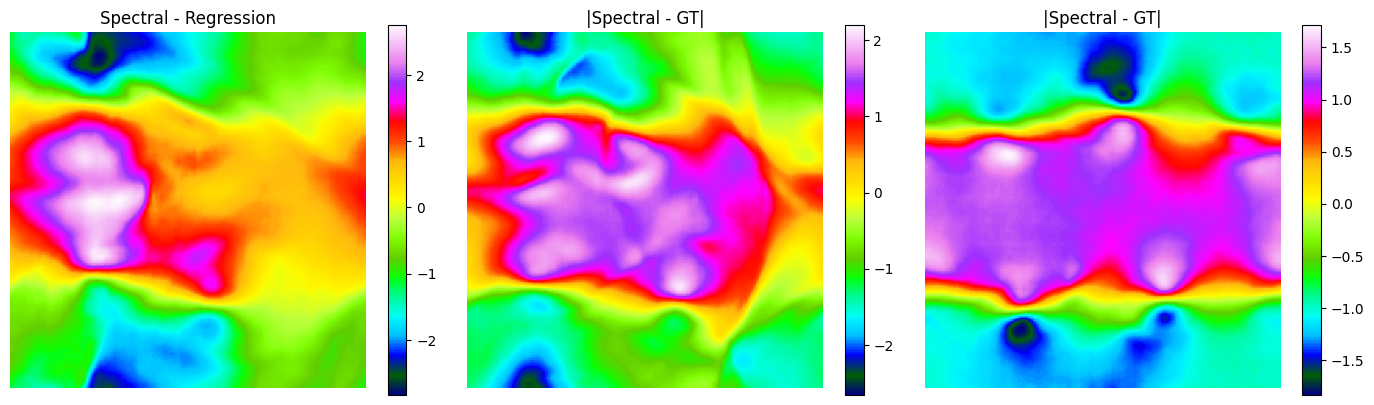

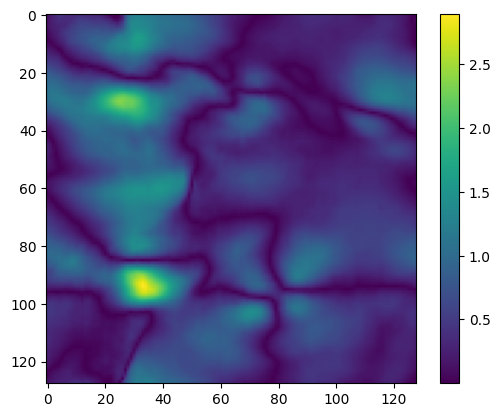

In [23]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

pred_save = np.load(f"/cluster/work/math/braonic/TrainedModels/OOD_Generalization/pdegym_plus/PDEGYM_PLUS_10ep_ViTB_regression/predictions_ns_shear_gencfd_generated_data2/sample_{id}_pred.npy")


im1 = axes[0].imshow(to_resolver[0],cmap=cmap)
axes[0].set_title("Spectral - Regression")
fig.colorbar(im,orientation='vertical')
axes[0].axis('off')

# Show each image
im2 = axes[1].imshow(pred_save[0], cmap=cmap)
axes[1].set_title('|Spectral - GT|')
axes[1].axis('off')

# Show each image
im3 = axes[2].imshow(to_trainer[0], cmap=cmap)
axes[2].set_title('|Spectral - GT|')
axes[2].axis('off')

fig.colorbar(im1,orientation='vertical')
fig.colorbar(im2,orientation='vertical')
fig.colorbar(im3,orientation='vertical')


plt.tight_layout()
plt.show()

plt.imshow(abs(to_trainer[0] - to_resolver[0]))
plt.colorbar()


In [11]:
a = np.load("/cluster/work/math/braonic/TrainedModels/OOD_Generalization/pdegym_plus/PDEGYM_PLUS_10ep_ViTB_regression/predictions_spectral_resolver_64_steps_1_ensemble_True_renorm_0.1_guidance_eul_riemann_curved_/physical_stats.npz")

In [25]:
np.mean(np.abs(a["mean_gt"][1]-a["mean_gen"][1]))/np.mean(np.abs(a["mean_gt"][1]))

0.60781384

In [110]:
import xarray as xr

path = '/cluster/work/math/braonic/data/ns_shear2d_gencfd/ne_shear2d_gencfd.nc'

ds = xr.open_dataset(path)
print(ds)


<xarray.Dataset> Size: 39GB
Dimensions:  (member: 99000, time: 2, x: 128, y: 128, c: 3)
Dimensions without coordinates: member, time, x, y, c
Data variables:
    data     (member, time, x, y, c) float32 39GB ...


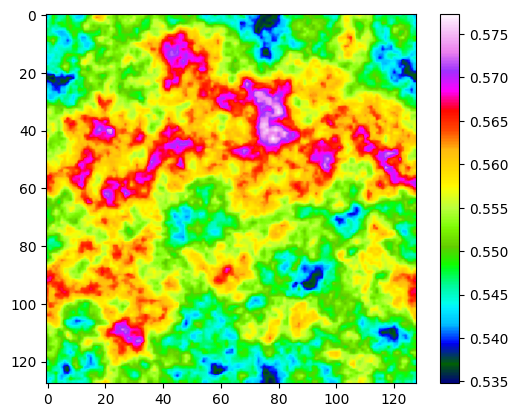

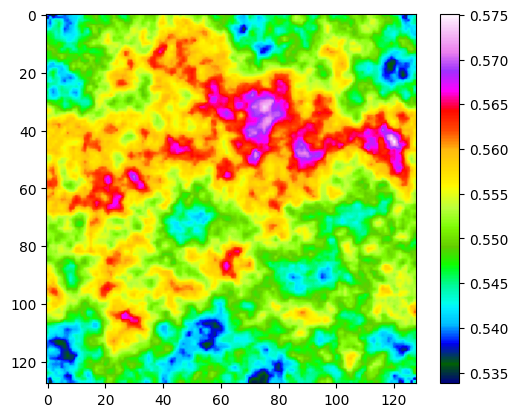

In [27]:
#vmin = np.min(a["mean_gt"][0])
plt.imshow(a["mean_gt"][3], cmap = "gist_ncar")
plt.colorbar()
plt.show()
plt.imshow(a["mean_gen"][3], cmap = "gist_ncar")
plt.colorbar()

In [7]:
#!/usr/bin/env python3
# List variables in a NetCDF file using netCDF4

from netCDF4 import Dataset
import sys
from textwrap import indent

def print_var(vname, var, prefix=""):
    dims = "(" + ", ".join(var.dimensions) + ")"
    dtype = str(var.dtype)
    try:
        shape = tuple(var.shape)
    except Exception:
        shape = "?"
    attrs_to_show = ["long_name", "standard_name", "units", "description"]
    shown = {k: getattr(var, k) for k in attrs_to_show if hasattr(var, k)}
    attr_str = ", ".join(f'{k}="{v}"' for k, v in shown.items())
    line = f"{prefix}{vname} {dims}  dtype={dtype}  shape={shape}"
    if attr_str:
        line += f"  [{attr_str}]"
    print(line)

def print_group(grp, path="/"):
    print(f"\n# Group: {path}")
    if grp.dimensions:
        print("Dimensions:")
        for dname, dim in grp.dimensions.items():
            size = len(dim) if not dim.isunlimited() else "UNLIMITED"
            print(f"  {dname} = {size}")
    else:
        print("Dimensions: (none)")

    if grp.variables:
        print("Variables:")
        for vname, var in grp.variables.items():
            print_var(vname, var, prefix="  ")
    else:
        print("Variables: (none)")

    # Recurse into subgroups
    for gname, subgrp in grp.groups.items():
        subpath = path.rstrip("/") + "/" + gname
        print_group(subgrp, subpath)

def main(nc_path):
    with Dataset(nc_path, "r") as ds:
        # Global attributes summary (optional)
        print(f"File: {nc_path}")
        if ds.ncattrs():
            print("Global attributes:")
            for a in ds.ncattrs():
                # Avoid dumping extremely long attrs
                val = getattr(ds, a)
                s = str(val)
                if len(s) > 200:
                    s = s[:200] + "…"
                print(indent(f"{a}: {s}", "  "))
        
        print_group(ds, "/")

#path = "/cluster/work/math/camlab-data/data/diffusion_project/macro_micro_in_distribution_nothing_N128.nc"
path = "/cluster/work/math/camlab-data/data/diffusion_project/macro_micro_id_2d.nc"
path = "/cluster/work/math/camlab-data/data/diffusion_project/ddsl_fast_nothing_128_tr2.nc"
main(path)


File: /cluster/work/math/camlab-data/data/diffusion_project/ddsl_fast_nothing_128_tr2.nc

# Group: /
Dimensions:
  member = 99000
  time = 2
  x = 128
  y = 128
  c = 3
Variables:
  data (member, time, x, y, c)  dtype=float32  shape=(99000, 2, 128, 128, 3)


In [11]:
import xarray as xr
import matplotlib.pyplot as plt

# Path to your NetCDF file
path = "/cluster/work/math/camlab-data/data/diffusion_project/ddsl_fast_nothing_128_tr2.nc"
ds = xr.open_dataset(path)



In [29]:
print(ds)

<xarray.Dataset> Size: 39GB
Dimensions:  (member: 99000, time: 2, x: 128, y: 128, c: 3)
Dimensions without coordinates: member, time, x, y, c
Data variables:
    data     (member, time, x, y, c) float32 39GB ...


In [35]:
u = ds["data"][:500,:,:,:,0]
v = ds["data"][:500,:,:,:,1]


In [36]:
import numpy as np

print(np.mean(u), np.std(u))
print(np.mean(v), np.std(v))


<xarray.DataArray 'data' ()> Size: 4B
array(-7.450581e-12, dtype=float32) <xarray.DataArray 'data' ()> Size: 4B
array(0.8701995, dtype=float32)
<xarray.DataArray 'data' ()> Size: 4B
array(5.4278192e-12, dtype=float32) <xarray.DataArray 'data' ()> Size: 4B
array(0.38360977, dtype=float32)


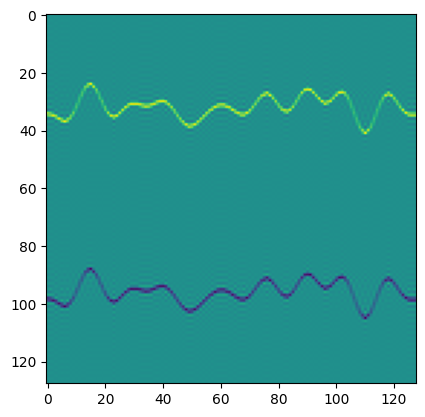

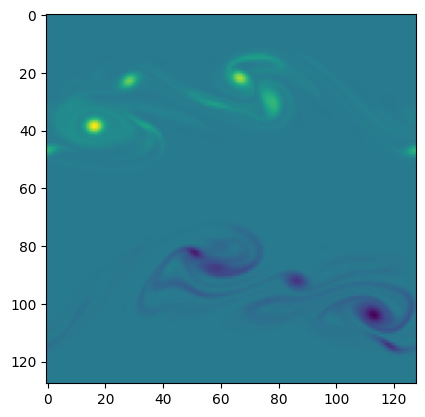

In [27]:
plt.imshow(ds["data"][98000,0,:,:,2])
plt.show()
plt.imshow(ds["data"][110,1,:,:,2])

In [8]:
import numpy as np
import matplotlib.pyplot as plt

X = np.load("/cluster/work/math/braonic/TrainedModels/OOD_Generalization/pdegym_plus/PDEGYM_PLUS_10ep_ViTB_regression/predictions_ns_shear_gencfd_generated_data/samples_steps_1_1.0_128_out.npy")
Y = np.load("/cluster/work/math/braonic/TrainedModels/OOD_Generalization/pdegym_plus/PDEGYM_PLUS_10ep_ViTB_regression/predictions_ns_shear_gencfd_generated_data/samples_steps_1_1.0_128_pred.npy")



In [9]:
X.shape

(128, 9, 128, 128)

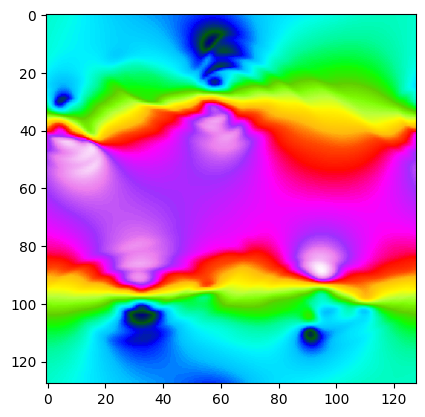

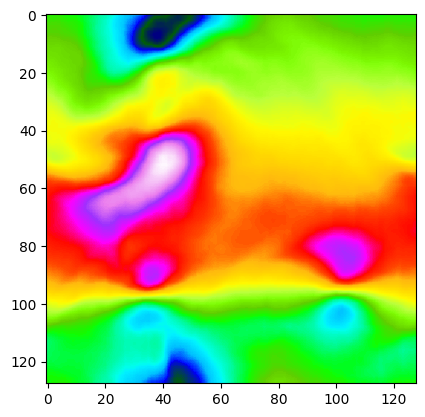

In [10]:
plt.imshow(X[6,1], cmap = "gist_ncar")
plt.show()
plt.imshow(Y[6,1], cmap = "gist_ncar")

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import xarray as xr

path = "/cluster/work/math/braonic/TrainedModels/OOD_Generalization/pdegym_plus/PDEGYM_PLUS_10ep_ViTB_regression/predictions_ns_shear_gencfd_generated_data/ns_shear_gencfd_pdegym_plus_pred_128.nc"
ds = xr.open_dataset(path)

path2 = "/cluster/work/math/braonic/data/ns_shear2d_gencfd/ne_shear2d_gencfd.nc"
ds2 = xr.open_dataset(path2)
print(ds)

path_poseidon = "/cluster/work/math/camlab-data/synthetic/IEU_2D_DDSLTracer.nc"
dsp = xr.open_dataset(path_poseidon)
print(dsp)


<xarray.Dataset> Size: 17MB
Dimensions:       (member: 128, time: 1, x: 128, y: 128)
Coordinates:
  * member        (member) int32 512B 0 1 2 3 4 5 6 ... 122 123 124 125 126 127
Dimensions without coordinates: time, x, y
Data variables:
    time_i        (time) int32 4B ...
    time_j        (time) int32 4B ...
    u             (member, time, x, y) float32 8MB ...
    v             (member, time, x, y) float32 8MB ...
    written_mask  (member) int8 128B ...
Attributes:
    description:  PDEGym+ predictions
    note:         C order [rho,u,v,p]; time indices stored in time_i/time_j  ...
    created_by:   streaming-writer
    layout:       variables: rho,u,v,p with dims (member,time,x,y) -- OR just...
<xarray.Dataset> Size: 83GB
Dimensions:  (member: 20000, time: 21, x: 128, y: 128)
Coordinates:
  * member   (member) int64 160kB 0 1 2 3 4 5 ... 19995 19996 19997 19998 19999
  * time     (time) float32 84B 0.0 0.05 0.1 0.15 0.2 ... 0.8 0.85 0.9 0.95 1.0
  * x        (x) float32 512B 0.0

(99000, 2, 128, 128, 3) (128, 1, 128, 128)


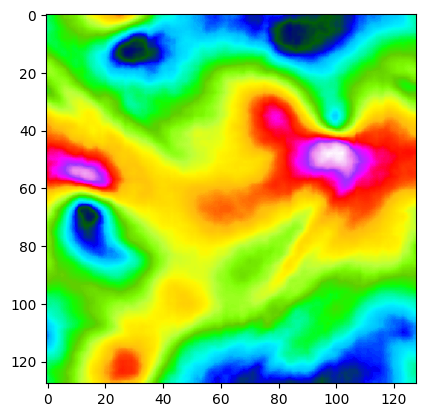

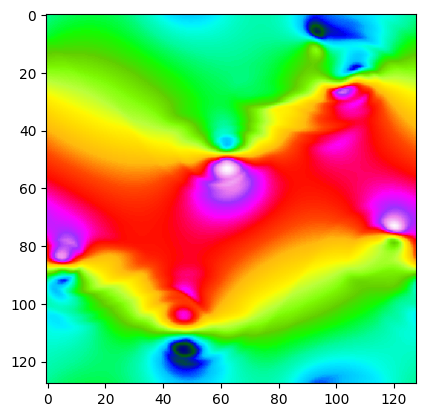

In [2]:
print(ds2["data"].shape, ds["u"].shape)
n = 1

pred = ds["u"][n,0]
out = ds2["data"][n,1,:,:,0]

plt.imshow(pred, cmap = "gist_ncar", vmin = np.min(pred),  vmax = np.max(pred))
plt.show()
plt.imshow(out, cmap = "gist_ncar")

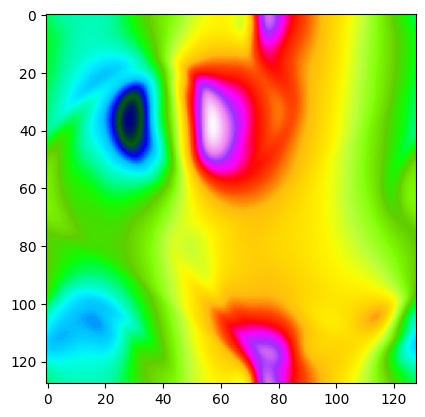

In [3]:
plt.imshow(dsp["u"][0,20], cmap = "gist_ncar")

In [53]:
import numpy as np
from netCDF4 import Dataset

file_path = "/cluster/scratch/braonic/data_atm_msc_moist/atm_msc_moist_gen_data_tmp.nc"

# Open the NetCDF file in read-only mode
ds = Dataset(file_path, mode="r")

# Print all dimensions and their sizes
print("Dimensions:")
for name, dim in ds.dimensions.items():
    print(f"  {name}: {len(dim)}")

# Print all variables and their shapes
print("\nVariables:")
for name, var in ds.variables.items():
    print(f"  {name}: shape = {var.shape}, dims = {var.dimensions}")

# Example: inspect a specific data variable (replace 'your_var_name' with actual name)
var = ds.variables["time_i"]
print("Data shape:", var.shape, np.array(var))
var = ds.variables["time_j"]

pred1 = ds.variables["v"][2,8]
pred2 = ds.variables["v"][2,9]

print("Data shape:", var.shape, np.array(var))

# Close file
ds.close()


Dimensions:
  member: 300
  time: 120
  x: 96
  y: 96
  z: 192

Variables:
  member: shape = (300,), dims = ('member',)
  time_i: shape = (120,), dims = ('time',)
  time_j: shape = (120,), dims = ('time',)
  u: shape = (300, 120, 96, 96, 192), dims = ('member', 'time', 'x', 'y', 'z')
  v: shape = (300, 120, 96, 96, 192), dims = ('member', 'time', 'x', 'y', 'z')
  w: shape = (300, 120, 96, 96, 192), dims = ('member', 'time', 'x', 'y', 'z')
  temperature: shape = (300, 120, 96, 96, 192), dims = ('member', 'time', 'x', 'y', 'z')
  qt: shape = (300, 120, 96, 96, 192), dims = ('member', 'time', 'x', 'y', 'z')
  written_mask: shape = (300,), dims = ('member',)
  written_steps: shape = (300,), dims = ('member',)
Data shape: (120,) [ 0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  1  1  1  1  1  1  1  1  1
  1  1  1  1  1  2  2  2  2  2  2  2  2  2  2  2  2  2  3  3  3  3  3  3
  3  3  3  3  3  3  4  4  4  4  4  4  4  4  4  4  4  5  5  5  5  5  5  5
  5  5  5  6  6  6  6  6  6  6  6  6  7  7  7  

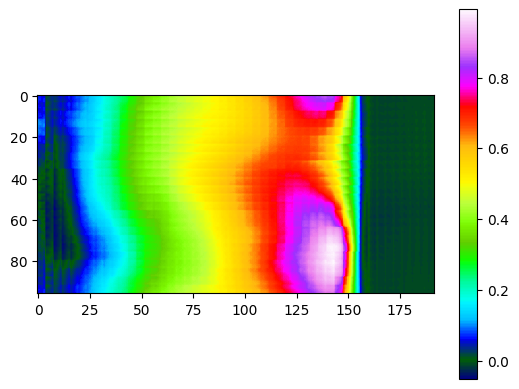

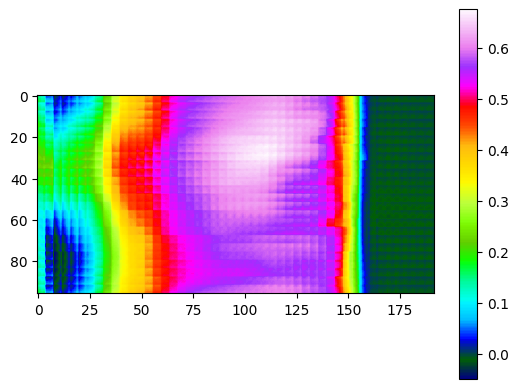

In [54]:
import matplotlib.pyplot as plt

plt.imshow(np.array(pred1[:,16,:]), cmap = "gist_ncar")
plt.colorbar()
plt.show()
plt.imshow(np.array(pred2[:,16,:]), cmap = "gist_ncar")
plt.colorbar()



In [52]:
print(pred2[48,:,192:])

[]


In [5]:
from dataloader.dataloader_poseidon import ShearLayerGenCFDMicroMacroTimeDataset,ShearLayerGenCFDTimeDataset, TaylorGreen3dTimeDataset, CloudShock3dTimeDataset,MERRA2Dataset,RiemannEllipse3dTimeDataset, Riemann3dTimeDataset, RiemannCurved3dTimeDataset, ShearLayer3dTimeDataset, KelvinHelmholtz3dTimeDataset, OrszagTang8TimeDataset, CahnEquations,PoissonGaussians,WaveSeismic,WaveGaussians,RichtmyerMeshkov,BrownianBridgeTimeDataset, VortexSheetTimeDataset, SinesTimeDataset, SinesEasyTimeDataset, PiecewiseConstantsTimeDataset, GaussiansTimeDataset, ComplicatedShearLayerTimeDataset, EulerGaussTimeDataset, RiemannTimeDataset,RiemannKHTimeDataset, RiemannCurvedTimeDataset, KelvinHelmholtzTimeDataset, Helmholtz

ds = ShearLayer3dTimeDataset(max_num_time_steps = 4, 
                                        time_step_size = 1,
                                        fix_input_to_time_step = None,
                                        which = "train",
                                        resolution = 64,
                                        in_dist = True,
                                        in_dim = 5,
                                        out_dim=5,
                                        num_trajectories = min(1000, 9000),
                                        data_path = "",
                                        time_input = True,
                                        masked_input = None,
                                        allowed_transitions = [1,2,3,4,5],
                                        copy_to_local_scratch = False,
                                        perturb_p = False) 

5 5
time_indices [(0, 1), (0, 2), (0, 3), (0, 4), (1, 2), (1, 3), (1, 4), (2, 3), (2, 4), (3, 4)]


In [6]:
idx = 0
sample = ds[idx]

In [7]:
sample[0]

0.05